# 3D Grid Visualization

This notebook demonstrates how to load and visualize a 3-D grid from [Generalized Grid Description (GGD) in IMAS](https://imas-data-dictionary.readthedocs.io/en/latest/ggd_guide/doc.html).

The example test data was calculated by JOREK for an ITER disruption scenario.

In [1]:
import numpy as np
import ultraplot as uplt
from imas import DBEntry
from rich import print as rprint
from rich.table import Table

from cherab.imas.datasets import iter_jorek
from cherab.imas.ids.common import get_ids_time_slice
from cherab.imas.ids.common.ggd import load_grid

# Set dark background for plots
uplt.rc.style = "dark_background"

## Retrieve ITER JOREK sample data

In [2]:
path = iter_jorek()

Output()

Retrieve the GGD data belonging to the [radiation IDS](https://imas-data-dictionary.readthedocs.io/en/latest/generated/ids/radiation.html).

In [3]:
with DBEntry(path, "r") as entry:
    ids = get_ids_time_slice(entry, "radiation")
    grid = load_grid(ids.grid_ggd[0])

14:37:50 INFO     Parsing data dictionary version 4.1.1 @dd_zip.py:89


14:37:51 INFO     Parsing data dictionary version 4.0.0 @dd_zip.py:89


/tmp/ipykernel_3598/3961500530.py:2: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_disruption_113112_1.nc'. Falling back to 'get' and re-slicing via the IMAS memory backend.
  ids = get_ids_time_slice(entry, "radiation")


Show the grid specification

In [4]:
table = Table(show_header=False, title="Grid specification")
table.add_row("Grid name", str(grid.name))
table.add_row("Number Faces", str(grid.num_faces))
table.add_row("Number Toroidal", str(grid.num_toroidal))
table.add_row("Number Cell", str(grid.num_cell))
table.add_row("Shape of vertices array", str(grid.vertices.shape))
table.add_row("Shape of cells array", str(grid.cells.shape))
rprint(table)

           Grid specification            
┌─────────────────────────┬─────────────┐
│ Grid name               │ JOREK mesh  │
│ Number Faces            │ 6398        │
│ Number Toroidal         │ 64          │
│ Number Cell             │ 409472      │
│ Shape of vertices array │ (418304, 3) │
│ Shape of cells array    │ (409472, 8) │
└─────────────────────────┴─────────────┘

## Visualize the cross-section of the grid

Show the grid lines and cell volume map in the poloidal cross-section of the grid.

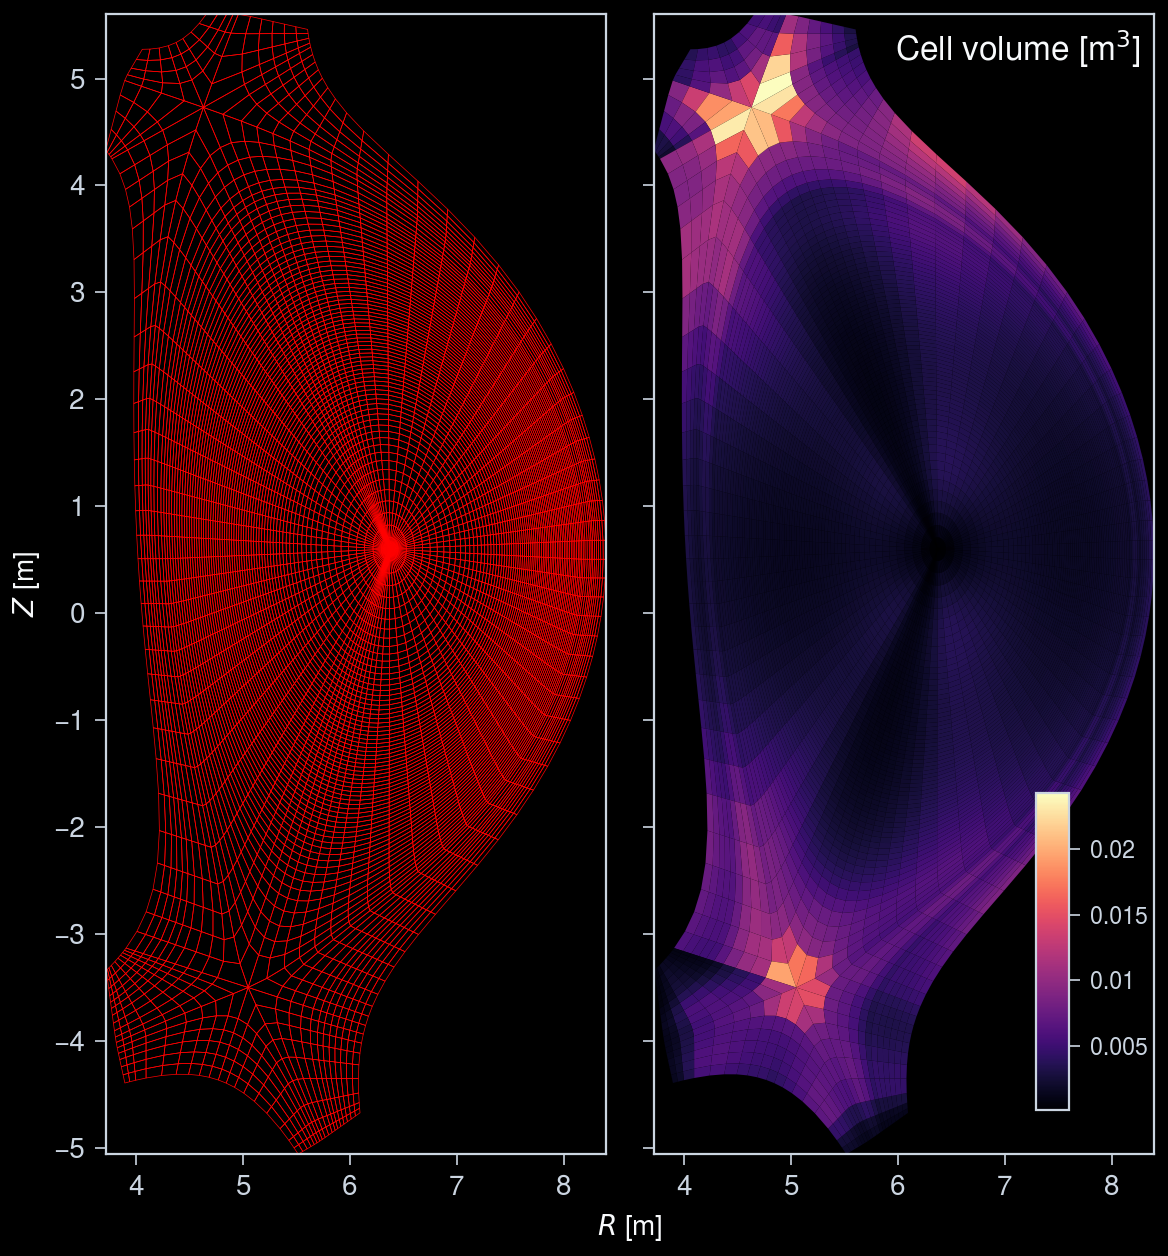

In [5]:
fig, axs = uplt.subplots(ncols=2)
# Plot the grid mesh in 2D cross-section
grid.plot_mesh(ax=axs[0], edgecolor="red")

# Plot the cell volume map in 2D cross-section
ax = grid.plot_mesh(ax=axs[1], data=grid.cell_volume[: grid.num_faces])
ax.collections[0].set_cmap("magma")

ax.colorbar(
    ax.collections[0],
    tickdir="out",
    loc="lr",
    orientation="vertical",
    ticklabelsize="small",
    length=5,
    frame=False,
)
ax.format(
    urtitle="Cell volume [m$^3$]",
    titleborder=False,
)

# Format the axes
axs.format(xlocator=1, ylocator=1)

Plot center points of cells

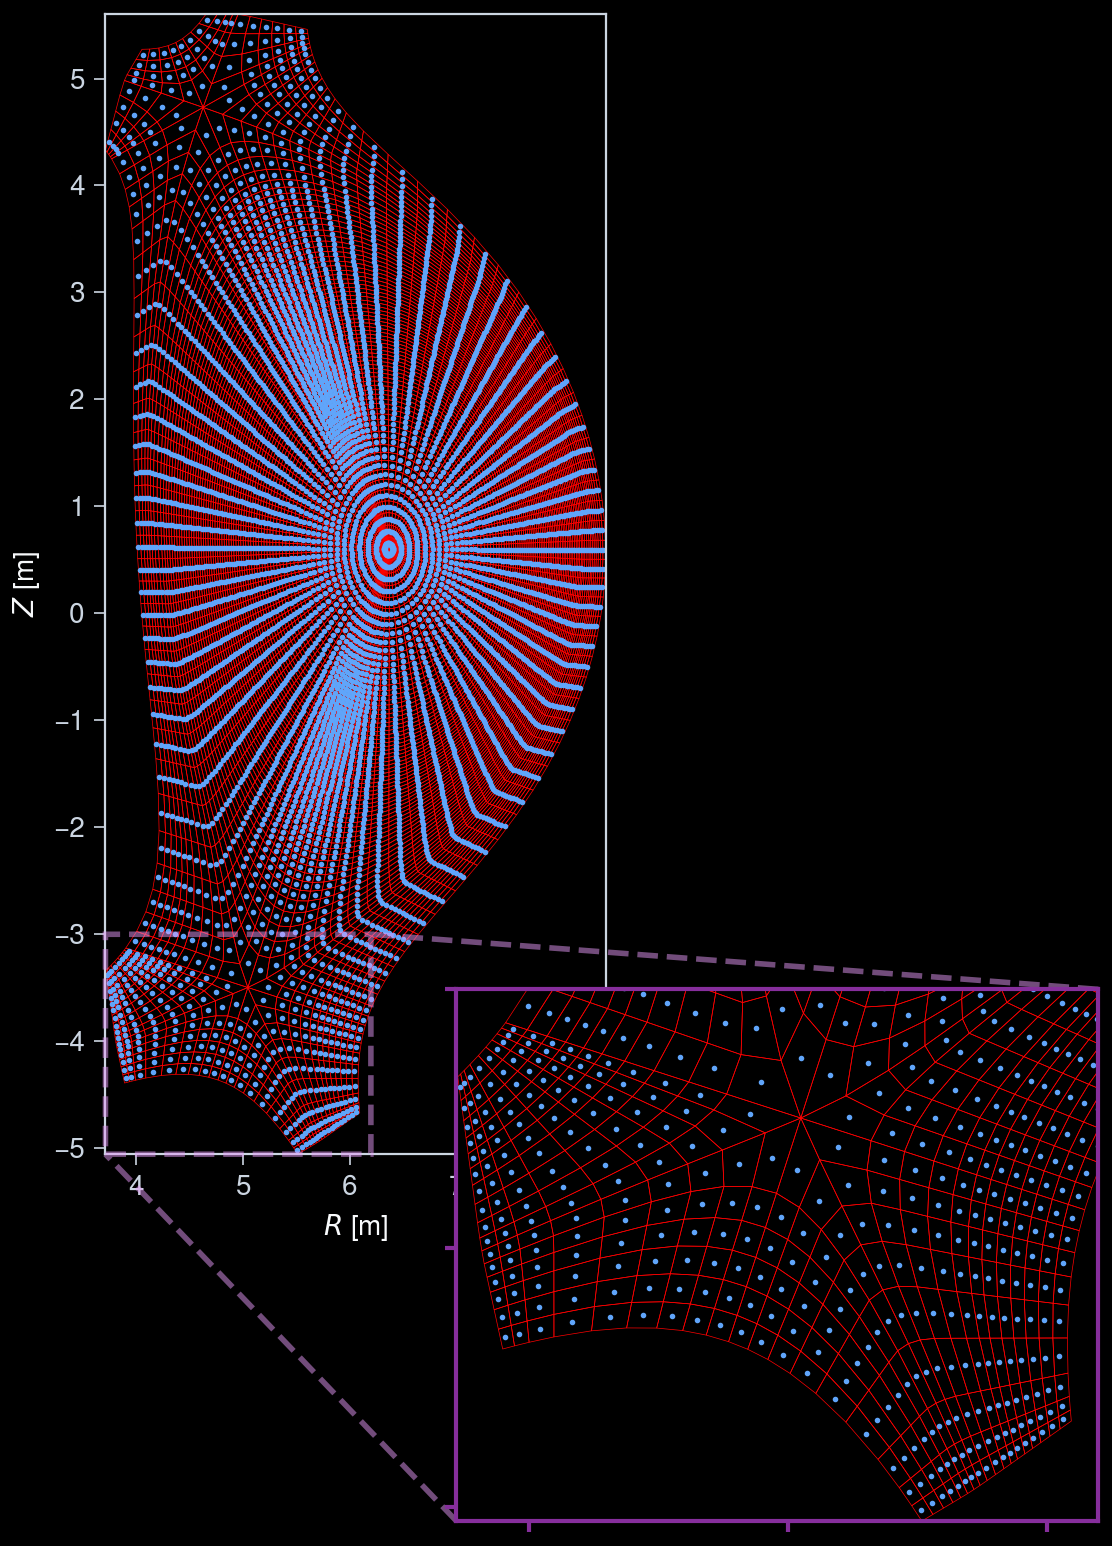

In [6]:
# Extract cell center points for one toroidal slice
cell_centers = grid.cell_centre[: grid.num_faces, :]

# Calculate the (r, z) coordinates
r_coords = np.hypot(cell_centers[:, 0], cell_centers[:, 1])
z_coords = cell_centers[:, 2]

fig, ax = uplt.subplots()

# Plot grid and cell centers in the poloidal cross-section
grid.plot_mesh(
    ax=ax,
    edgecolor="red",
)
ax.scatter(r_coords, z_coords, s=1, c="C0")
ax.format(
    xlocator=1,
    ylocator=1,
)

# Zoom in around divertor region
ix = ax.inset(
    [7.0, -9, 6, 6],
    transform="data",
    zoom_kw={"ec": "grape3", "ls": "--", "lw": 2},
)
grid.plot_mesh(ax=ix, edgecolor="red")
ix.scatter(r_coords, z_coords, s=1, c="C0")
ix.format(
    xlim=(ax.get_xlim()[0], 6.2),
    ylim=(ax.get_ylim()[0], -3.0),
    aspect="equal",
    color="grape9",
    linewidth=1.5,
    ticklabelweight="bold",
    xlocator=1,
    ylocator=1,
    xformatter="none",
    yformatter="none",
    xlabel="",
    ylabel="",
)

## Cut out quarter of the torus

In [7]:
grid_cut = grid.subset(np.arange(grid.num_faces * grid.num_toroidal // 4))

## Visualize the exterior mesh

To keep the visualization readable and efficient to render, only the exterior faces of the quarter-torus grid are shown. Faces shared by adjacent cells and all internal edges are omitted, while the edges of the exterior cells are retained to show the surface mesh structure.

This filtering affects only the visualization; the underlying volume mesh is not modified or downsampled. [Plotly](https://plotly.com/python/) is used to render the exterior mesh.

In [8]:
import plotly.graph_objects as go

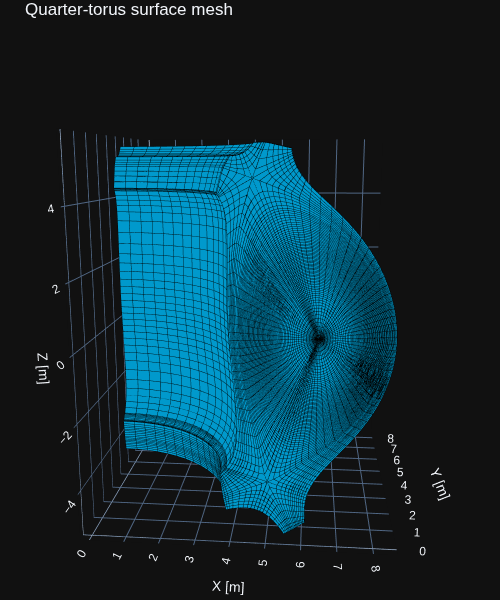

In [9]:
verts = grid_cut.vertices
cells = grid_cut.cells

# Extract the six quadrilateral faces of each hexahedral cell.  Working with
# cell faces, rather than tetrahedral faces, allows shared internal faces to
# cancel even when adjacent cells use different tetrahedral diagonals.
cell_face_indices = np.array(
    [
        [0, 1, 2, 3],
        [4, 5, 6, 7],
        [0, 1, 5, 4],
        [1, 2, 6, 5],
        [2, 3, 7, 6],
        [3, 0, 4, 7],
    ]
)
cell_faces = cells[:, cell_face_indices].reshape(-1, 4)

# A face that occurs only once belongs to the exterior of the selected grid.
_, face_indices, counts = np.unique(
    np.sort(cell_faces, axis=1),
    axis=0,
    return_index=True,
    return_counts=True,
)
surface_quads = cell_faces[face_indices[counts == 1]]

# Split exterior quads into triangles for Plotly's Mesh3d and discard
# zero-area triangles caused by padded triangular cells.
surface_faces = np.vstack([surface_quads[:, [0, 1, 2]], surface_quads[:, [0, 2, 3]]])
face_vertices = verts[surface_faces]
face_area_twice = np.linalg.norm(
    np.cross(
        face_vertices[:, 1] - face_vertices[:, 0],
        face_vertices[:, 2] - face_vertices[:, 0],
    ),
    axis=1,
)
surface_faces = surface_faces[face_area_twice > 1e-12]

# Draw only exterior cell edges.  These reveal the original mesh structure
# without sending the hidden volume edges to the renderer.
surface_edges = np.vstack(
    [
        surface_quads[:, [0, 1]],
        surface_quads[:, [1, 2]],
        surface_quads[:, [2, 3]],
        surface_quads[:, [3, 0]],
    ]
)
edge_vertices = verts[surface_edges]
surface_edges = surface_edges[
    np.linalg.norm(edge_vertices[:, 1] - edge_vertices[:, 0], axis=1) > 1e-12
]
surface_edges = np.unique(np.sort(surface_edges, axis=1), axis=0)

x, y, z = verts[:, 0], verts[:, 1], verts[:, 2]

# Customize edge appearance here.
edge_color = "black"
edge_width = 1.5

# Convert edge index pairs to line segments separated by NaN for Plotly.
edge_xyz = verts[surface_edges]
xe = np.column_stack(
    [edge_xyz[:, 0, 0], edge_xyz[:, 1, 0], np.full(len(surface_edges), np.nan)]
).ravel()
ye = np.column_stack(
    [edge_xyz[:, 0, 1], edge_xyz[:, 1, 1], np.full(len(surface_edges), np.nan)]
).ravel()
ze = np.column_stack(
    [edge_xyz[:, 0, 2], edge_xyz[:, 1, 2], np.full(len(surface_edges), np.nan)]
).ravel()

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=x,
            y=y,
            z=z,
            i=surface_faces[:, 0],
            j=surface_faces[:, 1],
            k=surface_faces[:, 2],
            color="deepskyblue",
            flatshading=True,
            hoverinfo="skip",
            showscale=False,
            name="Surface",
        ),
        go.Scatter3d(
            x=xe,
            y=ye,
            z=ze,
            mode="lines",
            line=dict(color=edge_color, width=edge_width),
            name="Surface mesh",
            hoverinfo="skip",
        ),
    ]
)

fig.update_layout(
    title="Quarter-torus surface mesh",
    width=500,
    height=600,
    scene=dict(
        xaxis_title="X [m]",
        yaxis_title="Y [m]",
        zaxis_title="Z [m]",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    scene_camera=dict(
        eye=dict(x=0.2, y=-2.25, z=0.5),
    ),
    template="plotly_dark",
)
fig.show(
    renderer="png",
)